# Analiza Danych (Python) - Lekcja 2

1. [GitHub i GitKraken (z Lekcji 1)](#0.-GitHub-i-GitKraken-(z-Lekcji-1))
2. [Statystyka opisowa i praca z danymi](#1.-Statystyka-opisowa-i-praca-z-danymi)
3. [Typy danych i skale pomiarowe](#2.-Typy-danych-i-skale-pomiarowe)
4. [Miary tendencji centralnej i rozproszenia](#3.-Miary-tendencji-centralnej-i-rozproszenia)
5. [Wizualizacja rozkładów i zależności](#4.-Wizualizacja-rozkładów-i-zależności)
6. [Zadania](#5.-Zadania)
7. [Najczęstsze błędy](#Najczęstsze-błędy)


# 1. Statystyka opisowa i praca z danymi

## Populacja, próba, losowość

- **Populacja**: pełny zbiór obiektów, o których chcemy wnioskować.
- **Próba**: część populacji, którą realnie obserwujemy.
- **Losowość**: mechanizm doboru i zmienności wyników; wpływa na to, czy wnioski da się uogólniać.

W praktyce analitycznej:
- pracujemy na próbie,
- opisujemy próbę statystykami opisowymi,
- oceniamy, na ile wynik może reprezentować populację.

## Cel tej lekcji

- poprawnie opisać dane liczbowe i kategoryczne,
- rozumieć, które miary mają sens dla danej skali,
- tworzyć wykresy rozkładów i zależności,
- formułować krótkie, poprawne wnioski z danych.


# 2. Typy danych i skale pomiarowe

## Typy danych w pandas

Najczęściej spotkasz:
- `object` / `string` (tekst),
- `int64`, `float64` (liczby),
- `category` (kategorie),
- `datetime64[ns]` (daty).

## Skale pomiarowe (statystyka)

- **Nominalna**: kategorie bez porządku (np. płeć, grupa).
- **Porządkowa**: kategorie z porządkiem (np. skala Likerta 1-5).
- **Przedziałowa**: różnice mają sens, brak naturalnego zera.
- **Ilorazowa**: różnice i ilorazy mają sens, istnieje zero absolutne.

Zasada praktyczna: najpierw ustal skalę zmiennej, dopiero potem dobieraj miary i wykres.


# 3. Miary tendencji centralnej i rozproszenia

## Najważniejsze miary

- Tendencja centralna: `mean`, `median`, `mode`.
- Rozproszenie: `std`, `var`, `min`, `max`, `quantile`, `IQR`.
- Rozkład empiryczny: jak często obserwujemy wartości (histogram, gęstość, percentyle).

W praktyce:
- dla rozkładów skośnych częściej raportujemy medianę i IQR,
- dla rozkładów zbliżonych do normalnych często raportujemy średnią i odchylenie standardowe.


# 4. Wizualizacja rozkładów i zależności

## Minimalny zestaw wykresów

- histogram + KDE: rozkład jednej zmiennej liczbowej,
- boxplot: porównanie rozkładów między grupami + obserwacje odstające,
- barplot/countplot: zmienne kategoryczne,
- scatterplot: zależność między dwiema zmiennymi liczbowymi.

Dobra praktyka:
- zawsze podpisane osie,
- tytuł mówiący, co porównujesz,
- krótki komentarz interpretacyjny pod wykresem.


# 5. Zadania

## Pliki do ćwiczeń

Pliki wejściowe znajdują się w folderze `dane_lekcja2/`:

- `participants.csv`
- `survey_likert.csv`
- `experiment_trials.csv`
- `outliers_rt.csv` 


## Zadanie 1

Cel: szybka diagnostyka jakości danych i struktury tabeli.

Wprowadzenie:
Najpierw zawsze sprawdź rozmiar danych, typy kolumn i braki. To pozwala uniknąć błędnych analiz na kolejnych etapach.

Instrukcja:
1. Wczytaj `participants.csv`.
2. Sprawdź liczbę wierszy i kolumn.
3. Sprawdź typy kolumn.
4. Policz braki danych w każdej kolumnie.

Wymagane funkcje:
- `pd.read_csv()`
- `DataFrame.shape`
- `DataFrame.info()`
- `DataFrame.isna()`
- `DataFrame.sum()`

Kryterium zaliczenia:
- pokazany rozmiar danych, typy i liczba braków.

Checkpoint:
- pokaż prowadzącemu wynik `df.info()` i `df.isna().sum()`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dane_lekcja2/participants.csv')

print(df.shape,df.info(),df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   participant_id    800 non-null    int64  
 1   age               800 non-null    int64  
 2   gender            800 non-null    str    
 3   group             800 non-null    str    
 4   education         800 non-null    str    
 5   sleep_hours       777 non-null    float64
 6   stress_level      786 non-null    float64
 7   reaction_time_ms  800 non-null    float64
 8   memory_score      786 non-null    float64
 9   attention_score   800 non-null    float64
 10  session_date      800 non-null    str    
 11  city              800 non-null    str    
dtypes: float64(5), int64(2), str(5)
memory usage: 75.1 KB
(800, 12) None participant_id       0
age                  0
gender               0
group                0
education            0
sleep_hours         23
stress_level        14
reaction_time

## Zadanie 2

Cel: rozpoznanie typów danych i skal pomiarowych.

Wprowadzenie:
Typ techniczny (`dtype`) i skala statystyczna to nie to samo. Np. skala Likerta jest zwykle liczbowo zapisana jako `int`, ale statystycznie jest porządkowa.

Instrukcja:
1. Dla każdej kolumny z `participants.csv` zapisz proponowaną skalę: nominalna/porządkowa/ilorazowa.
2. Utwórz tabelę podsumowującą z kolumnami: `zmienna`, `dtype`, `skala`, `uzasadnienie`.

Wymagane funkcje:
- `DataFrame.dtypes`
- `pd.DataFrame()`

Kryterium zaliczenia:
- tabela zawiera wszystkie kolumny i sensowne przypisanie skali.

Checkpoint:
- pokaż gotową tabelę klasyfikacji zmiennych.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html


In [4]:
techniczne = df.dtypes.astype(str)

klasyfikacja = pd.DataFrame({
    'zmienna': df.columns,
    'dtype': techniczne.values,
    'skala': [
        'nominalna',    # participant_id
        'ilorazowa',    # age
        'nominalna',    # gender
        'nominalna',    # group
        'porządkowa',   # education
        'ilorazowa',    # sleep_hours
        'porządkowa',   # stress_level
        'ilorazowa',    # reaction_time_ms
        'ilorazowa',    # memory_score
        'ilorazowa',    # attention_score
        'przedziałowa', # session_date
        'nominalna'     # city
    ],
    'uzasadnienie': [
        'To identyfikator. który jest unikatowy.', #participant_id
        'Zero to brak wieku – nieskonczenie wiele wartosci które mogą być wielokrotnie uzyte', #age
        'Niehierachiczne kategorie', #gender
        'Przypisanie do grupy bez hierarchii.', #group
        'Kategorie zdecydowanie hierarchiczne', #education
        'Rowniez wiele wartosci tak jak przy age', #sleep_hours
        'Subiektywna ocena na skali, i brak równego odstępu', #stress_level
        'Czas mierzony w ms.', #reaction_time_ms
        'Wynik punktowy testu czyli mamy typową miarę ilościową', #memory_score
        'Tak samo, jak poprzednio', #attention_score
        'Data to przedział czasu z róznicami miedzy poszczegolnymi dniami.', #session_date
        'Unikatowe, niehierarchiczne nazwy miast.' #city
    ]
})

klasyfikacja

,zmienna,dtype,skala,uzasadnienie
0,participant_id,int64,nominalna,To identyfikator. który jest unikatowy.
1,age,int64,ilorazowa,Zero to brak wieku – nieskonczenie wiele warto...
2,gender,str,nominalna,Niehierachiczne kategorie
3,group,str,nominalna,Przypisanie do grupy bez hierarchii.
4,education,str,porządkowa,Kategorie zdecydowanie hierarchiczne
5,sleep_hours,float64,ilorazowa,Rowniez wiele wartosci tak jak przy age
6,stress_level,float64,porządkowa,"Subiektywna ocena na skali, i brak równego ods..."
7,reaction_time_ms,float64,ilorazowa,Czas mierzony w ms.
8,memory_score,float64,ilorazowa,Wynik punktowy testu czyli mamy typową miarę i...
9,attention_score,float64,ilorazowa,"Tak samo, jak poprzednio"


## Zadanie 3

Cel: obliczenie miar tendencji centralnej i rozproszenia.

Wprowadzenie:
Opis statystyczny powinien zawierać zarówno miary centralne, jak i rozproszenie. Sama średnia nie wystarcza.

Instrukcja:
1. Dla zmiennych `reaction_time_ms`, `memory_score`, `attention_score` oblicz:
- średnią,
- medianę,
- dominantę,
- odchylenie standardowe,
- kwartyle (`Q1`, `Q3`) i `IQR`.
2. Zbierz wynik do jednej tabeli.

Wymagane funkcje:
- `DataFrame.mean()`
- `DataFrame.median()`
- `DataFrame.mode()`
- `DataFrame.std()`
- `DataFrame.quantile()`

Kryterium zaliczenia:
- jedna tabela z kompletem miar dla trzech zmiennych.

Checkpoint:
- pokaż tabelę i krótko wskaż, która zmienna ma największe rozproszenie.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.median.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html


In [ ]:
kolumny = ['reaction_time_ms','memory_score','attention_score']
Q1 = df[kolumny].quantile(0.25)
Q3 = df[kolumny].quantile(0.75)
IQR = Q3 - Q1

tabela = pd.DataFrame({
    'średnia': df[kolumny].mean(),
    'mediana': df[kolumny].median(),
    'dominanta': df[kolumny].mode().iloc[0], 
    'odchylenie_std': df[kolumny].std(),
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR
})

tabela
#Widać, ze najwiekszy rozrzut ma czas reakcji w ms

,średnia,mediana,dominanta,odchylenie_std,Q1,Q3,IQR
reaction_time_ms,546.827000,542.95,537.8,84.917711,488.875,604.400,115.525
memory_score,69.151908,69.20,63.2,11.871745,61.300,77.600,16.300
attention_score,67.604000,68.20,67.8,11.754694,59.700,75.325,15.625


## Zadanie 4

Cel: analiza rozkładu empirycznego jednej zmiennej.

Wprowadzenie:
Rozkład empiryczny pokazuje, gdzie koncentrują się obserwacje i czy występuje skośność.

Instrukcja:
1. Dla `reaction_time_ms` narysuj histogram (`bins` min. 20) i linię KDE.
2. Oblicz percentyle: 10%, 25%, 50%, 75%, 90%.
3. Napisz 2-3 zdania interpretacji.

Wymagane funkcje:
- `sns.histplot()`
- parametry `bins`, `kde`
- `Series.quantile()`
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

Kryterium zaliczenia:
- poprawny wykres + percentyle + krótka interpretacja.

Checkpoint:
- pokaż wykres i wartości percentyli.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.histplot.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html


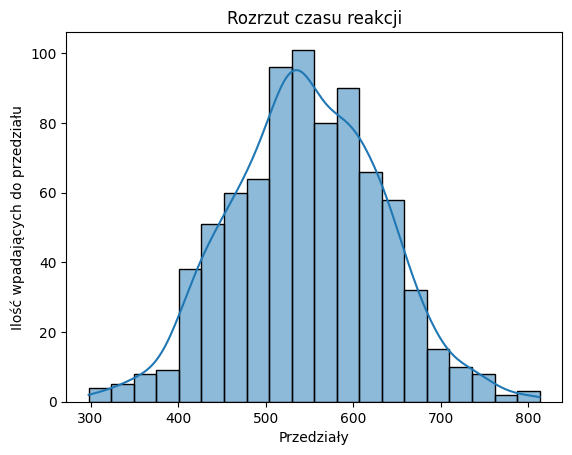

Percentyle dla czasów reakcji:
0.10    436.520
0.25    488.875
0.50    542.950
0.75    604.400
0.90    651.130
Name: reaction_time_ms, dtype: float64


In [ ]:
sns.histplot(data=df['reaction_time_ms'],bins=20, kde = True)

plt.title('Rozrzut czasu reakcji')
plt.xlabel('Przedziały')
plt.ylabel("Ilość wpadających do przedziału")

plt.show()
print("Percentyle dla czasów reakcji:")
print(df['reaction_time_ms'].quantile([0.1,0.25,0.5,0.75,0.9]))

#"Górka" jest dosyć symetryczna, w związku z tym przypomina klasyczny dzwon i nie ma w tych danych zbyt duzych skrrajnosci
#(Są w miarę równe z obydwu stron)

#Ekstremalne szybkie reakcje, tj. ponizej 436.5 ms i powyzej 651.130 trafiają się najrzadziej, zgodnie z oczekiwaniami.
#Największe zagęszczenie wystąpień jest w okolicach mediany (542.95), co jest zgodne z rozkładem normalnym. 
#Dokładnie połowa badanych osiągnęła typowe wartosci pomiędzy pierwszym a trzecim kwartylem (między 488.875 a 604.400)


## Zadanie 5

Cel: porównanie grup przy użyciu statystyki opisowej.

Wprowadzenie:
`groupby` pozwala porównać profile grup bez budowy modeli inferencyjnych.

Instrukcja:
1. Policz średni i medianowy `reaction_time_ms` oraz `memory_score` w podziale na `group`.
2. Rozszerz analizę o podział jednocześnie po `group` i `gender`.

Wymagane funkcje:
- `DataFrame.groupby()`
- `DataFrame.agg()`

Kryterium zaliczenia:
- dwie tabele: (a) wg `group`, (b) wg `group` i `gender`.

Checkpoint:
- wskaż, która grupa ma szybszy średni czas reakcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.agg.html


In [25]:
# Miejsce na Twoje rozwiązanie.
tabela_grupy = df.groupby('group')[['reaction_time_ms', 'memory_score']].agg(['mean', 'median'])
tabela_grupy_plec = df.groupby(['group', 'gender'])[['reaction_time_ms', 'memory_score']].agg(['mean', 'median'])

print(tabela_grupy)
print('\n')
print(tabela_grupy_plec)




                reaction_time_ms         memory_score       
                            mean  median         mean median
group                                                       
eksperymentalna        534.77425  533.45    69.394898  70.00
kontrolna              558.87975  563.95    68.910152  67.95


                       reaction_time_ms        memory_score       
                                   mean median         mean median
group           gender                                            
eksperymentalna K            531.700000  532.6    67.658416  69.05
                M            538.006154  537.6    71.241053  71.15
kontrolna       K            558.719487  564.2    69.106283  67.80
                M            559.032195  563.7    68.725616  68.20


## Zadanie 6

Cel: wizualizacja zależności między zmiennymi liczbowymi.

Wprowadzenie:
Na tym etapie nie testujemy hipotez, tylko opisujemy siłę i kierunek zależności.

Instrukcja:
1. Oblicz macierz korelacji dla zmiennych liczbowych z `participants.csv`.
2. Narysuj heatmapę korelacji.
3. Narysuj `scatterplot` dla `sleep_hours` vs `memory_score`.

Wymagane funkcje:
- `DataFrame.corr()`
- `sns.heatmap()`
- `sns.scatterplot()`
- parametr `annot=True` (heatmap)

Kryterium zaliczenia:
- macierz korelacji + 2 wykresy (heatmap + scatterplot).

Checkpoint:
- wskaż jedną dodatnią i jedną ujemną zależność.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
- https://seaborn.pydata.org/generated/seaborn.heatmap.html
- https://seaborn.pydata.org/generated/seaborn.scatterplot.html


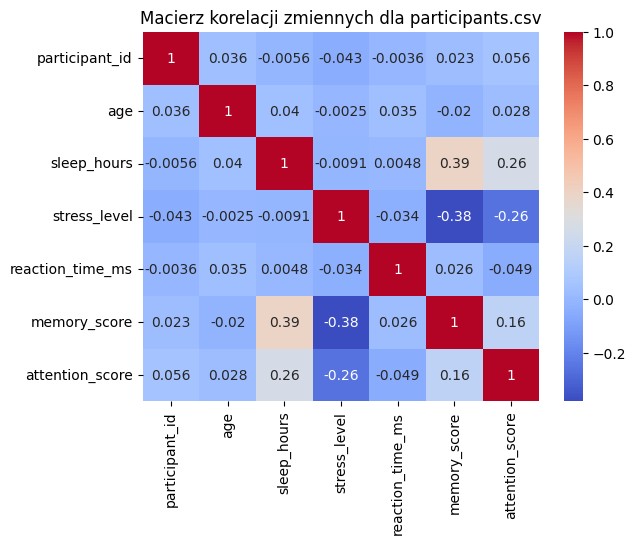

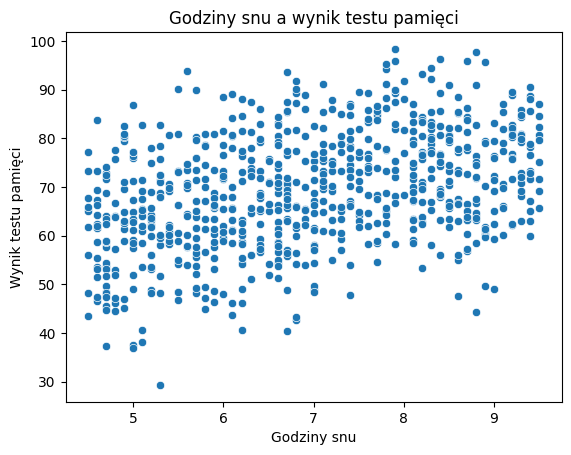

In [ ]:
korelacje = df.corr(numeric_only=True)
sns.heatmap(korelacje, annot=True, cmap='coolwarm') #dla coolwarm lepsze kolorki
plt.title('Macierz korelacji zmiennych dla participants.csv')
plt.show()

sns.scatterplot(data=df, x='sleep_hours', y='memory_score')
plt.title('Godziny snu a wynik testu pamięci')
plt.xlabel('Godziny snu')
plt.ylabel('Wynik testu pamięci')
plt.show()

#Silną dodatnią zaleznosc widac w korelacji miedzy sleep_hours a memory_score, co zreszta pokazuje drugi wykres. 
#Ujemną natomiast zdecydowanie widać w np. memory_score a stress_level, co jest zrozumiale.

## Zadanie 7

Cel: detekcja obserwacji odstających.

Wprowadzenie:
Outliery silnie wpływają na średnią i odchylenie standardowe, dlatego warto je diagnozować osobno.

Instrukcja:
1. Wczytaj `outliers_rt.csv`.
2. Dla `rt_ms` oblicz `Q1`, `Q3`, `IQR`.
3. Wyznacz dolną i górną granicę metody IQR (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`).
4. Odfiltruj obserwacje odstające i policz ich liczbę.
5. Pokaż boxplot `rt_ms` w podziale na `group`.

Wymagane funkcje:
- `Series.quantile()`
- filtrowanie logiczne `DataFrame`
- `sns.boxplot()`

Kryterium zaliczenia:
- podane granice IQR, liczba outlierów i wykres boxplot.

Checkpoint:
- pokaż tabelę z pierwszymi 10 outlierami.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html
- https://seaborn.pydata.org/generated/seaborn.boxplot.html


KWartyle Q1, Q3, IQR:
517.425 606.4749999999999 89.04999999999995


Dolna i górna granica IQR:
383.85 740.0499999999998


Jest 27 obserwacji poza dopuszczalnym przedziałem.
     observation_id            group   rt_ms
1                 2        kontrolna  1400.2
16               17  eksperymentalna  1107.2
52               53        kontrolna  1653.7
55               56        kontrolna  1411.8
72               73        kontrolna  1776.4
131             132  eksperymentalna   824.2
136             137  eksperymentalna  1114.6
141             142        kontrolna   767.3
178             179  eksperymentalna  1159.9
218             219        kontrolna   748.8


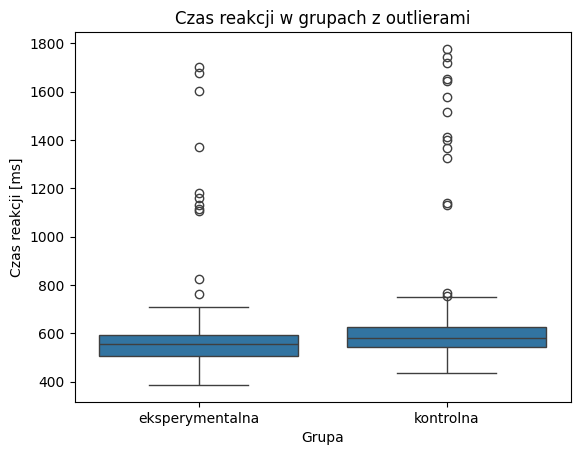

In [2]:
df = pd.read_csv('dane_lekcja2/outliers_rt.csv')

Q1 = df['rt_ms'].quantile(0.25)
Q3 = df['rt_ms'].quantile(0.75)
IQR = Q3 - Q1

print("KWartyle Q1, Q3, IQR:")
print(Q1,Q3,IQR)
print('\n')

iqr_dol = Q1 - 1.5*IQR
iqr_gora =  Q3 + 1.5*IQR

print("Dolna i górna granica IQR:")
print(iqr_dol,iqr_gora)
print('\n')


odrzut = df[(df['rt_ms'] < iqr_dol) | (df['rt_ms'] > iqr_gora)]
print(f"Jest {len(odrzut)} obserwacji poza dopuszczalnym przedziałem.")
print(odrzut.head(10))

sns.boxplot(data=df,x='group',y='rt_ms')
plt.title('Czas reakcji w grupach z outlierami')
plt.ylabel('Czas reakcji [ms]')
plt.xlabel('Grupa')
plt.show()

## Zadanie 8

Cel: połączenie opisu liczbowego i wizualnego w krótkim raporcie.

Wprowadzenie:
To mini-symulacja realnej pracy analitycznej: wybierasz kluczowe miary i wykresy, a potem formułujesz wnioski.

Instrukcja:
1. Użyj `participants.csv` i przygotuj 1 tabelę podsumowującą (min. 4 miary).
2. Dodaj 2 wykresy: jeden rozkładu, jeden zależności.
3. Napisz 5 krótkich wniosków (każdy 1 zdanie) opartych na danych.

Wymagane funkcje:
- dowolne z poprzednich zadań (`describe`, `groupby`, `histplot`, `boxplot`, `scatterplot`, `heatmap`).

Kryterium zaliczenia:
- tabela + 2 wykresy + 5 wniosków spójnych z wynikami.

Checkpoint:
- przedstaw mini-raport w jednej sekcji notebooka.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
- https://seaborn.pydata.org/


              age  memory_score  stress_level
count  800.000000    786.000000    786.000000
mean    28.813750     69.151908      5.375318
std      5.635491     11.871745      2.862069
min     19.000000     29.300000      1.000000
25%     24.000000     61.300000      3.000000
50%     29.000000     69.200000      5.000000
75%     33.250000     77.600000      8.000000
max     38.000000    100.000000     10.000000


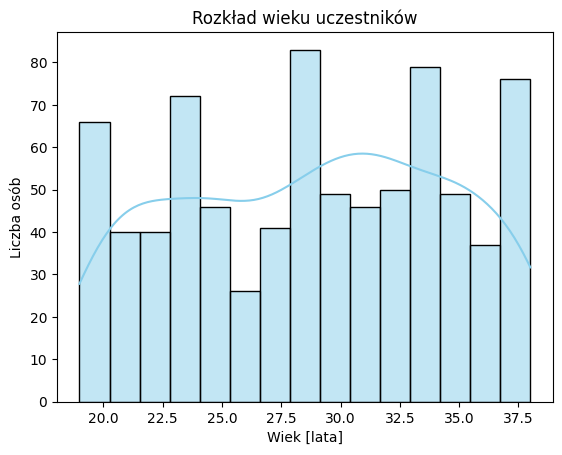

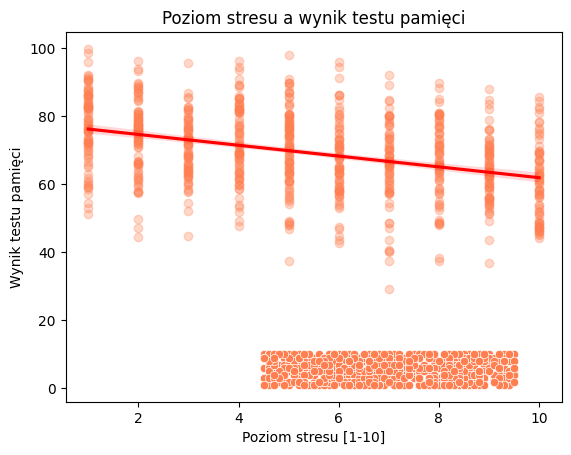

In [77]:
df = pd.read_csv('dane_lekcja2/participants.csv')

print(df[['age','memory_score','stress_level']].describe())

sns.histplot(data=df, x='age', bins=15, kde=True, color='skyblue')
plt.title('Rozkład wieku uczestników')
plt.xlabel('Wiek [lata]')
plt.ylabel('Liczba osób')
plt.show()

sns.scatterplot(data=df, x='sleep_hours', y='stress_level', color='coral')

sns.regplot(data=df, x='stress_level', y='memory_score', 
            y_jitter=0.3, scatter_kws={'alpha': 0.3, 'color': 'coral'}, 
            line_kws={'color': 'red'},)
plt.title('Poziom stresu a wynik testu pamięci')
plt.xlabel('Poziom stresu [1-10]')
plt.ylabel('Wynik testu pamięci')
plt.show()


Wnioski:


1. Średni wiek badanych uczestników wynosi około 28.7 lat. Przynajmniej połowa uczestników ma 29 lat lub mniej. Najstarszy badany miał 40 lat.

2. Średni wynik testu pamięci wynosił 69.15 punktów, przy czym jest spory rozrzut między najmniejszą (29.30) a największą (100) ilością punktów.

3. Wykres wieku (A) nie tworzy idelnego dzwonu (tj. rozkładu normalnego), po obu stronach mediany widać dwa szczyty.

4. Wykres B ewidentnie pokazuje ujemną korelację między poziomem stresu a wynikiem testu pamięci.

5. Mozna więc dojść do wniosku, ze poziom stresu ujemnie wplywa na zdolności kognitywne w tej próbie.

## Zadanie 9 - dodatkowe

Cel: praca na skali porządkowej (Likert) i świadomy dobór miar.

Wprowadzenie:
Dane Likerta są porządkowe, więc poza średnią warto raportować medianę i rozkład odpowiedzi.

Instrukcja:
1. Wczytaj `survey_likert.csv`.
2. Dla pytań `q1`-`q8` oblicz medianę i dominantę.
3. Dla każdego pytania policz rozkład odpowiedzi (`value_counts`) i udział procentowy.

Wymagane funkcje:
- `pd.read_csv()`
- `DataFrame.median()`
- `DataFrame.mode()`
- `Series.value_counts()`
- parametr `normalize=True`

Kryterium zaliczenia:
- tabela median i dominant + min. jedna tabela rozkładu procentowego.

Checkpoint:
- wskaż pytanie z najwyższą medianą.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.median.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html


In [31]:
df = pd.read_csv('dane_lekcja2/survey_likert.csv')

kolumny = ['q1','q2','q3','q4','q5','q6','q7','q8']

print(df[kolumny].median())
print('\n')
print(df[kolumny].mode().iloc[0])
print('\n')
for pytanie in kolumny:
    print(df[pytanie].value_counts(normalize=True).sort_index() * 100)

q1    3.0
q2    3.0
q3    3.0
q4    3.0
q5    3.0
q6    3.0
q7    3.0
q8    3.0
dtype: float64


q1    1
q2    2
q3    3
q4    4
q5    3
q6    1
q7    5
q8    1
Name: 0, dtype: int64


q1
1    21.428571
2    21.285714
3    19.714286
4    18.714286
5    18.857143
Name: proportion, dtype: float64
q2
1    18.428571
2    22.857143
3    16.857143
4    20.142857
5    21.714286
Name: proportion, dtype: float64
q3
1    19.714286
2    20.714286
3    23.857143
4    15.428571
5    20.285714
Name: proportion, dtype: float64
q4
1    19.571429
2    18.857143
3    20.000000
4    21.142857
5    20.428571
Name: proportion, dtype: float64
q5
1    21.428571
2    19.000000
3    22.428571
4    17.000000
5    20.142857
Name: proportion, dtype: float64
q6
1    21.142857
2    20.142857
3    20.714286
4    19.571429
5    18.428571
Name: proportion, dtype: float64
q7
1    20.000000
2    19.571429
3    19.857143
4    19.285714
5    21.285714
Name: proportion, dtype: float64
q8
1    22.000000
2    18.142857
3    

## Zadanie 10 - dodatkowe

Cel: porównanie rozkładów między warunkami eksperymentalnymi.

Wprowadzenie:
Same średnie nie pokazują pełnego obrazu. Rozkład może różnić się szerokością i skośnością.

Instrukcja:
1. Wczytaj `experiment_trials.csv`.
2. Narysuj boxplot `rt_ms` w podziale na `condition`.
3. Dla każdej `condition` policz medianę i IQR dla `rt_ms`.

Wymagane funkcje:
- `pd.read_csv()`
- `sns.boxplot()`
- `groupby()` + `agg()`
- `quantile()`

Kryterium zaliczenia:
- wykres + tabela mediany i IQR dla A/B/C.

Checkpoint:
- wskaż warunek o największym rozproszeniu.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.boxplot.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html


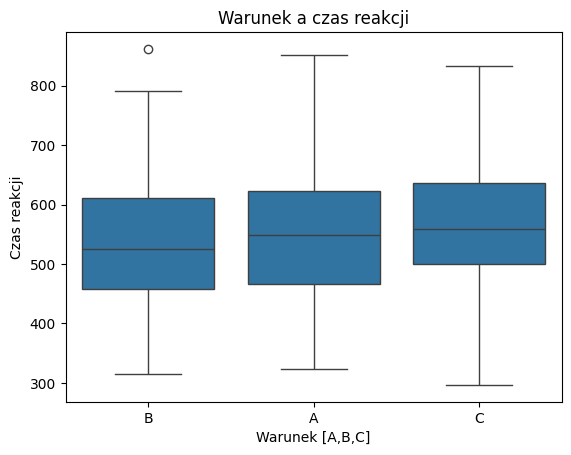

           Mediana     IQR
condition                 
A           549.05  622.25
B           525.90  610.35
C           559.40  636.00


,trial_id,participant_id,condition,difficulty,correct,rt_ms,confidence_1_5
0,1,758,B,hard,1,759.3,4
1,2,610,B,hard,1,615.6,3
2,3,516,B,easy,1,497.1,4
3,4,544,A,hard,0,613.5,3
4,5,337,C,easy,1,615.2,4
...,...,...,...,...,...,...,...
995,996,296,A,easy,1,444.8,3
996,997,303,B,easy,1,443.9,2
997,998,660,B,medium,1,509.5,3
998,999,588,A,easy,1,547.4,4


In [4]:
df = pd.read_csv('dane_lekcja2/experiment_trials.csv')
sns.boxplot(data=df, x = 'condition', y='rt_ms')
plt.title('Warunek a czas reakcji')
plt.xlabel('Warunek [A,B,C]')
plt.ylabel('Czas reakcji')
plt.show()

grupy = df.groupby('condition')['rt_ms']

mediana = grupy.median()

q1 = grupy.quantile(0.25)
q3 = grupy.quantile(0.75)
iqr = q3 - 1

tabela = pd.DataFrame({'Mediana': mediana, 'IQR': iqr})

print(tabela)

df




## Zadanie 11 - dodatkowe

Cel: analiza trafności odpowiedzi (`correct`) względem trudności zadania.

Wprowadzenie:
To przykład statystyki opisowej dla zmiennej binarnej (0/1): średnia = odsetek sukcesu.

Instrukcja:
1. W `experiment_trials.csv` policz odsetek poprawnych odpowiedzi dla poziomów `difficulty`.
2. Zwizualizuj wynik na wykresie słupkowym.
3. Dodaj etykiety procentowe nad słupkami.

Wymagane funkcje:
- `groupby()` + `mean()`
- `sns.barplot()` albo `plt.bar()`
- `matplotlib` (`plt.text` lub `bar_label`)

Kryterium zaliczenia:
- poprawny ranking poziomów trudności wg accuracy.

Checkpoint:
- wskaż różnicę (w p.p.) między `easy` i `hard`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.SeriesGroupBy.mean.html
- https://seaborn.pydata.org/generated/seaborn.barplot.html


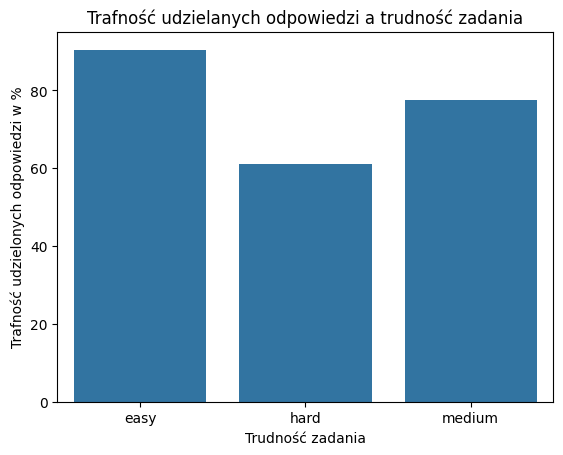

In [5]:
accuracy = df.groupby('difficulty')['correct'].mean().reset_index()
accuracy['accuracy_procent'] = accuracy['correct'] * 100

sns.barplot(data=accuracy, x='difficulty',y='accuracy_procent')
plt.title('Trafność udzielanych odpowiedzi a trudność zadania')
plt.xlabel('Trudność zadania')
plt.ylabel('Trafność udzielonych odpowiedzi w %')
plt.show()

## Zadanie 12 - dodatkowe

Cel: standaryzacja (z-score) i porównanie obserwacji na wspólnej skali.

Wprowadzenie:
Standaryzacja umożliwia porównywanie zmiennych mierzonych w różnych jednostkach.

Instrukcja:
1. W `participants.csv` wylicz z-score dla `reaction_time_ms` i `memory_score`.
2. Dodaj kolumny `rt_z` i `memory_z`.
3. Sprawdź, ilu uczestników ma `rt_z > 2` lub `rt_z < -2`.

Wymagane funkcje:
- operacje wektorowe na kolumnach
- `Series.mean()`
- `Series.std()`
- filtrowanie logiczne

Kryterium zaliczenia:
- poprawnie utworzone kolumny z-score i liczba skrajnych obserwacji.

Checkpoint:
- pokaż 10 rekordów o najwyższym `rt_z`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html


In [3]:
df = pd.read_csv('dane_lekcja2/participants.csv')

df['rt_z'] = (df['reaction_time_ms'] - df['reaction_time_ms'].mean()) / df['reaction_time_ms'].std()
df['memory_z'] = (df['memory_score'] - df['memory_score'].mean()) / df['memory_score'].std()

skrajne = df[(df['rt_z'] > 2) | (df['rt_z'] < -2)]
print(len(skrajne))

najwyzsze_z = df.sort_values(by='rt_z',ascending=False).head(10)

print(najwyzsze_z[['participant_id', 'reaction_time_ms', 'rt_z']])

38
     participant_id  reaction_time_ms      rt_z
264             265             812.9  3.133304
502             503             796.1  2.935465
287             288             795.2  2.924867
798             799             769.3  2.619866
268             269             768.3  2.608090
587             588             751.5  2.410251
774             775             751.2  2.406718
670             671             745.2  2.336062
238             239             744.9  2.332529
279             280             744.4  2.326641


## Zadanie 13 - dodatkowe

Cel: praca z przedziałami wartości (binning).

Wprowadzenie:
Binning upraszcza interpretację i pozwala porównywać profile grup.

Instrukcja:
1. Podziel `age` na przedziały: `18-22`, `23-27`, `28-32`, `33+`.
2. Policz liczebność uczestników w każdym przedziale.
3. Porównaj średni `memory_score` między przedziałami wieku.

Wymagane funkcje:
- `pd.cut()`
- `Series.value_counts()`
- `groupby()` + `mean()`

Kryterium zaliczenia:
- poprawna kolumna przedziałów wieku i tabela porównawcza.

Checkpoint:
- wskaż przedział wieku z najwyższym średnim `memory_score`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.cut.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html


In [ ]:
df = pd.read_csv('dane_lekcja2/participants.csv')
granice = [17, 22, 27, 32, 100]
etykiety = ['18-22', '23-27', '28-32', '33+']

df['grupa_wiekowa'] = pd.cut(df['age'], bins=granice, labels=etykiety)

ile = df['grupa_wiekowa'].value_counts().sort_index()
print(ile)

srednia = df.groupby('grupa_wiekowa')['memory_score'].mean()
print(srednia)

#Wygrala grupa wiekowa 28-32, minimalnie, ale jednak

grupa_wiekowa
18-22    146
23-27    185
28-32    228
33+      241
Name: count, dtype: int64
grupa_wiekowa
18-22    69.490909
23-27    69.135165
28-32    69.574890
33+      68.547436
Name: memory_score, dtype: float64


## Zadanie 14 - dodatkowe

Cel: porównanie średniej i mediany przy obecności obserwacji odstających.

Wprowadzenie:
Outliery mogą silnie przesuwać średnią, ale zwykle mniej wpływają na medianę.

Instrukcja:
1. Użyj `outliers_rt.csv`.
2. Policz średnią i medianę `rt_ms` dla całego zbioru.
3. Usuń outliery metodą IQR.
4. Ponownie policz średnią i medianę po oczyszczeniu.
5. Porównaj wyniki w krótkim komentarzu.

Wymagane funkcje:
- `mean()`, `median()`
- `quantile()`
- filtrowanie DataFrame

Kryterium zaliczenia:
- tabela/przedstawienie wyników „przed” i „po” oczyszczeniu.

Checkpoint:
- wskaż, która miara zmieniła się bardziej.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.median.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html


In [11]:
df = pd.read_csv('dane_lekcja2/outliers_rt.csv')
srednia_przed = df['rt_ms'].mean()
mediana_przed = df['rt_ms'].median()

Q1 = df['rt_ms'].quantile(0.25)
Q3 = df['rt_ms'].quantile(0.75)
IQR = Q3 - Q1
dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR

df_czyste = df[(df['rt_ms'] >= dolna_granica) & (df['rt_ms'] <= gorna_granica)]

srednia_po = df_czyste['rt_ms'].mean()
mediana_po = df_czyste['rt_ms'].median()

print("Przed:")
print(f"Średnia: {srednia_przed} ms")
print(f"Mediana: {mediana_przed} ms\n")

print("Po:")
print(f"Średnia: {srednia_po} ms")
print(f"Mediana: {mediana_po} ms")




Przed:
Średnia: 600.5844 ms
Mediana: 567.25 ms

Po:
Średnia: 560.222198731501 ms
Mediana: 563.0 ms


## Zadanie 15 - dodatkowe

Cel: mini-dashboard analityczny podsumowujący dane z lekcji.

Wprowadzenie:
Końcowe zadanie integruje całą lekcję: dane, statystyki opisowe i wizualizacje w jednym spójnym raporcie.

Instrukcja:
1. Przygotuj sekcję podsumowania na podstawie `participants.csv` i `experiment_trials.csv`.
2. Umieść:
- 1 tabelę statystyk opisowych,
- 3 wykresy (rozkład, porównanie grup, zależność),
- 6 krótkich wniosków.
3. Każdy wniosek ma odnosić się do konkretnej liczby lub wykresu.

Wymagane funkcje:
- `describe()`, `groupby()`, `agg()`
- `histplot()`, `boxplot()`/`barplot()`, `scatterplot()`

Kryterium zaliczenia:
- spójna sekcja raportowa z danymi liczbowymi i poprawną interpretacją.

Checkpoint:
- zaprezentuj mini-dashboard w 2-3 minuty.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://seaborn.pydata.org/


In [ ]:
# Miejsce na Twoje rozwiązanie.


## Najczęstsze błędy

- analizowanie średniej dla zmiennej porządkowej bez komentarza,
- pomijanie braków danych przed obliczeniami,
- brak podpisów osi i tytułu wykresu,
- mieszanie wniosków opisowych z przyczynowymi,
- interpretowanie korelacji jako dowodu przyczynowości.
